# Pipeline de Seleção de Features + Optuna + VotingClassifier

Classificação de tráfego MQTT (DoS vs normal).  
Fluxo: **pré-processamento → seleção de features → tuning Optuna por fold → VotingClassifier → melhor par (seletor × modelo)**

In [2]:
# ── Bibliotecas padrão ───────────────────────────────────────────
import warnings
from collections import defaultdict
from pathlib import Path
from statistics import mode as stat_mode

# ── Dados / matemática ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# ── Optuna ───────────────────────────────────────────────────────
import optuna

# ── mRMR (opcional) ──────────────────────────────────────────────
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️  mRMR não disponível. Instale com: pip install mrmr-selection")

# ── Configurações globais ─────────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

print("✅ Imports carregados.")


✅ Imports carregados.


## 1. Carregamento e Pré-processamento

Etapas:
1. Leitura do CSV
2. Tratamento de outliers via IQR capping (clip nos limites Q1−1.5×IQR / Q3+1.5×IQR)
3. Seleção e limpeza das features numéricas
4. Codificação do label target

In [3]:
# ── 1.1  Carregamento ────────────────────────────────────────────
DATA_PATH = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")

# ── 1.2  Tratamento de outliers (IQR capping) ───────────────────
def cap_outliers_iqr(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Limita valores aos limites IQR (Q1-1.5×IQR, Q3+1.5×IQR) por coluna."""
    df_out = df.copy()
    for col in columns:
        q1, q3 = df_out[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)
    return df_out

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_tratado = cap_outliers_iqr(df, numeric_cols)
print(f"Shape após tratamento: {df_tratado.shape}")

# ── 1.3  Seleção de features (remove colunas irrelevantes) ───────
COLUNAS_REMOVER = [
    "frame.time_delta_displayed", "frame.time_epoch", "frame.time_invalid",
    "frame.time_relative", "tcp.srcport", "tcp.dstport",
    "frame.coloring_rule.name", "frame.coloring_rule.string",
    "frame.comment", "frame.comment.expert", "frame.encap_type",
    "frame.file_off", "frame.ignored", "frame.incomplete",
    "frame.interface_id", "frame.interface_name", "frame.link_nr",
    "frame.marked", "frame.md5_hash", "frame.number", "frame.offset_shift",
    "mqtt.msgid", "mqtt.username", "mqtt.passwd",
    "mqtt.willmsg", "mqtt.willtopic",
]

num_df = df_tratado.select_dtypes(include=["int64", "float64"])
X = num_df.drop(columns=[c for c in COLUNAS_REMOVER if c in num_df.columns], errors="ignore")
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── 1.4  Encode do label ─────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df_tratado["type"])

print(f"Features: {X.shape[1]} | Amostras: {X.shape[0]}")
print(f"Classes: {le.classes_}  →  {dict(enumerate(le.classes_))}")


Shape original: (94625, 67)
Shape após tratamento: (94625, 67)
Features: 29 | Amostras: 94625
Classes: ['DoS' 'normal']  →  {0: 'DoS', 1: 'normal'}


## 2. Seletores de Características

Cada seletor é **reexecutado dentro de cada fold** para evitar data leakage.  
Ajuste `K_*` para controlar quantas features cada método seleciona.

In [4]:
# ── Quantidade de features por seletor ───────────────────────────
K_MRMR    = 15
K_FISHER  = 15
K_PEARSON = 15
K_TREE    = 15
K_SVC     = 15
K_LASSO   = 15


# ── Fisher Score (variância inter / intra classes) ────────────────
def fisher_score(X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
    """Calcula o Fisher's Score para cada feature numérica."""
    classes = np.unique(y)
    overall_mean = X.mean(axis=0).values
    scores = np.zeros(X.shape[1])

    for i in range(X.shape[1]):
        vals = X.iloc[:, i].values
        between, within = 0.0, 0.0
        for c in classes:
            mask = y == c
            nc = mask.sum()
            if nc > 0:
                mu_c = vals[mask].mean()
                between += nc * (mu_c - overall_mean[i]) ** 2
                within  += nc * vals[mask].var()
        scores[i] = between / within if within > 1e-10 else 0.0
    return scores


# ── Funções de seleção (uma por método) ──────────────────────────
def _selector_functions() -> dict:

    def select_mrmr(X_tr, y_tr):
        if not MRMR_AVAILABLE:
            return []
        try:
            return mrmr_classif(X_tr, y_tr, K=min(K_MRMR, X_tr.shape[1]))
        except Exception as e:
            print(f"[mRMR] erro: {e}")
            return []

    def select_fisher(X_tr, y_tr):
        scores = fisher_score(X_tr, y_tr)
        return (
            pd.DataFrame({"feature": X_tr.columns, "score": scores})
            .sort_values("score", ascending=False)
            .head(min(K_FISHER, len(X_tr.columns)))["feature"]
            .tolist()
        )

    def select_pearson(X_tr, y_tr):
        abs_corr = X_tr.apply(lambda col: abs(np.corrcoef(col, y_tr)[0, 1])).fillna(0)
        return abs_corr.sort_values(ascending=False).head(min(K_PEARSON, len(abs_corr))).index.tolist()

    def select_extratrees(X_tr, y_tr):
        et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        et.fit(X_tr, y_tr)
        imp = pd.Series(et.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_TREE, X_tr.shape[1])).index.tolist()

    def select_linearsvc_l1(X_tr, y_tr):
        # Usado APENAS como seletor de features (não como classificador final)
        X_sc = StandardScaler().fit_transform(X_tr)
        svc = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
        svc.fit(X_sc, y_tr)
        coef = np.mean(np.abs(svc.coef_), axis=0) if svc.coef_.ndim > 1 else np.abs(svc.coef_[0])
        imp = pd.Series(coef, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_SVC, X_tr.shape[1])).index.tolist()

    def select_lasso(X_tr, y_tr):
        X_sc = StandardScaler().fit_transform(X_tr)
        lasso = LassoCV(cv=3, random_state=42, max_iter=10000, n_jobs=-1)
        lasso.fit(X_sc, y_tr)
        imp = pd.Series(np.abs(lasso.coef_), index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_LASSO, X_tr.shape[1])).index.tolist()

    def select_low_variance(X_tr, y_tr):
        sel = VarianceThreshold(threshold=0.0)
        sel.fit(X_tr)
        return X_tr.columns[sel.get_support(indices=True)].tolist()

    return {
        "mRMR":         select_mrmr,
        "Fisher":       select_fisher,
        "Pearson":      select_pearson,
        "ExtraTrees":   select_extratrees,
        "LinearSVC_L1": select_linearsvc_l1,
        "LassoCV":      select_lasso,
        "LowVariance":  select_low_variance,
    }


selector_funcs = _selector_functions()
print("Seletores disponíveis:", list(selector_funcs.keys()))


Seletores disponíveis: ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC_L1', 'LassoCV', 'LowVariance']


## 3. Objetivos Optuna e Mapa de Modelos

Cada função define o espaço de busca de um modelo.  
O Optuna usa **TPE (Tree-structured Parzen Estimator)** + poda por mediana para encontrar os melhores hiperparâmetros.

In [5]:
# ── Funções objetivo: otimizadas via F1-macro em 3-fold CV interno ──

def _objective_rf(trial, X_tr, y_tr):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500, step=50),
        "max_depth":         trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42, "n_jobs": -1,
    }
    return cross_val_score(
        RandomForestClassifier(**params), X_tr, y_tr, cv=3, scoring="f1_macro", n_jobs=-1
    ).mean()


def _objective_lr(trial, X_tr, y_tr):
    # Espaço FIXO — Optuna não suporta espaços dinâmicos por parâmetro.
    # Combinação inválida (lbfgs + l1) é descartada via TrialPruned.
    solver  = trial.suggest_categorical("solver",  ["lbfgs", "saga"])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", None])

    if solver == "lbfgs" and penalty == "l1":
        raise optuna.exceptions.TrialPruned("lbfgs não suporta penalty=l1")

    params = {
        "C":        trial.suggest_float("C", 1e-3, 100.0, log=True),
        "solver":   solver,
        "penalty":  penalty,
        "max_iter": trial.suggest_int("max_iter", 500, 3000, step=500),
        "n_jobs": -1,
    }
    return cross_val_score(
        LogisticRegression(**params), X_tr, y_tr, cv=3, scoring="f1_macro", n_jobs=-1
    ).mean()


def _objective_gnb(trial, X_tr, y_tr):
    # GaussianNB tem apenas var_smoothing como hiperparâmetro relevante
    params = {
        "var_smoothing": trial.suggest_float("var_smoothing", 1e-11, 1e-5, log=True),
    }
    return cross_val_score(
        GaussianNB(**params), X_tr, y_tr, cv=3, scoring="f1_macro", n_jobs=-1
    ).mean()


def _objective_dt(trial, X_tr, y_tr):
    params = {
        "max_depth":         trial.suggest_categorical("max_depth", [None, 3, 5, 10, 20]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 15),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "splitter":          trial.suggest_categorical("splitter", ["best", "random"]),
        "random_state": 42,
    }
    return cross_val_score(
        DecisionTreeClassifier(**params), X_tr, y_tr, cv=3, scoring="f1_macro", n_jobs=-1
    ).mean()


# ── Mapa: nome → (objetivo, construtor, params_fixos) ────────────
MODEL_OBJECTIVES = {
    "RandomForest":       (_objective_rf,  RandomForestClassifier, {"random_state": 42, "n_jobs": -1}),
    "LogisticRegression": (_objective_lr,  LogisticRegression,     {"n_jobs": -1}),
    "GaussianNB":         (_objective_gnb, GaussianNB,             {}),
    "DecisionTree":       (_objective_dt,  DecisionTreeClassifier, {"random_state": 42}),
}

print("Modelos no pipeline Optuna:", list(MODEL_OBJECTIVES.keys()))


Modelos no pipeline Optuna: ['RandomForest', 'LogisticRegression', 'GaussianNB', 'DecisionTree']


## 4. Pipeline Core

| Função | Responsabilidade |
|---|---|
| `tune_models_for_fold` | Roda Optuna sobre `X_tr` de um fold, retorna instâncias + best_params |
| `_aggregate_hyperparams` | Consolida hiperparâmetros de N folds (média / moda) |
| `_compute_metrics` | Calcula todas as métricas para um modelo já treinado |
| `evaluate_selector_cv` | Loop CV externo completo para um seletor |

In [6]:
# ── Tuning Optuna por fold ────────────────────────────────────────
def tune_models_for_fold(
    X_tr: pd.DataFrame,
    y_tr: np.ndarray,
    n_trials: int = 30,
) -> tuple[dict, dict]:
    """
    Otimiza hiperparâmetros de cada modelo usando APENAS X_tr/y_tr
    (3-fold CV interno). Não vê o conjunto de validação externo.

    Retorna:
        instances   : {model_name: instância configurada, não treinada}
        best_params : {model_name: dict de hiperparâmetros}
    """
    instances, best_params = {}, {}

    for name, (obj_fn, constructor, fixed) in MODEL_OBJECTIVES.items():
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=42),
            pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
        )
        study.optimize(
            lambda trial, fn=obj_fn: fn(trial, X_tr, y_tr),
            n_trials=n_trials,
            show_progress_bar=False,
        )
        params = {**study.best_params, **fixed}
        best_params[name] = params.copy()
        instances[name]   = constructor(**params)

    return instances, best_params


# ── Agregação de hiperparâmetros entre folds ──────────────────────
def _aggregate_hyperparams(params_list: list[dict]) -> dict:
    """
    Consolida best_params de múltiplos folds em um único dict.
    - float contínuo → média aritmética
    - inteiro        → média arredondada
    - categórico     → moda (valor mais frequente)
    """
    if not params_list:
        return {}

    agg = {}
    for key in params_list[0]:
        vals = [p[key] for p in params_list if p.get(key) is not None]
        if not vals:
            agg[key] = None
        elif all(isinstance(v, float) for v in vals):
            agg[key] = float(np.mean(vals))
        elif all(isinstance(v, int) for v in vals):
            agg[key] = int(round(np.mean(vals)))
        else:
            raw = stat_mode(str(v) for v in vals)
            agg[key] = {"None": None, "True": True, "False": False}.get(raw, raw)
    return agg


# ── Cálculo de métricas de avaliação ─────────────────────────────
def _compute_metrics(model, X_val: pd.DataFrame, y_val: np.ndarray) -> dict:
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
    elif hasattr(model, "decision_function"):
        df_s = model.decision_function(X_val)
        if df_s.ndim == 1:
            df_s = np.vstack([-df_s, df_s]).T
        y_proba = np.exp(df_s) / np.exp(df_s).sum(axis=1, keepdims=True)
    else:
        y_proba = None

    ll = np.nan
    if y_proba is not None:
        try:
            ll = log_loss(y_val, y_proba)
        except Exception:
            pass

    return {
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_val, y_pred, average="macro", zero_division=0),
        "mcc":       matthews_corrcoef(y_val, y_pred),
        "logloss":   ll,
    }


# ── CV estratificado por seletor ──────────────────────────────────
def evaluate_selector_cv(
    selector_name: str,
    selector_fn,
    X_full: pd.DataFrame,
    y_full: np.ndarray,
    cv_splits: int = 5,
    n_optuna_trials: int = 30,
    voting: str = "soft",
) -> tuple[pd.DataFrame, dict]:
    """
    Para cada fold externo:
      1. Seleciona features com selector_fn(X_tr, y_tr)
      2. Otimiza hiperparâmetros via Optuna (apenas X_tr)
      3. Treina modelos individuais + VotingClassifier
      4. Avalia no fold de validação

    Retorna:
        df_results      : DataFrame com métricas mean/std por modelo
        best_hyperparams: {model_name: hiperparâmetros agregados}
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    all_metrics     = defaultdict(lambda: defaultdict(list))
    fold_hyperparams = defaultdict(list)

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_full, y_full), start=1):
        print(f"  [Fold {fold_idx}/{cv_splits}] {selector_name} — tunando…")

        X_tr,  X_val  = X_full.iloc[tr_idx],  X_full.iloc[val_idx]
        y_tr,  y_val  = y_full[tr_idx],        y_full[val_idx]

        # Seleção de features dentro do fold
        cols = selector_fn(X_tr, y_tr)
        if not cols:
            print("    ⚠ Seletor retornou lista vazia — fold ignorado.")
            continue

        X_tr_s, X_val_s = X_tr[cols], X_val[cols]

        # Tuning Optuna (sem ver X_val)
        model_instances, best_params_fold = tune_models_for_fold(
            X_tr_s, y_tr, n_trials=n_optuna_trials
        )
        for name, params in best_params_fold.items():
            fold_hyperparams[name].append(params)

        # Treina modelos individuais
        trained = {}
        for name, model in model_instances.items():
            model.fit(X_tr_s, y_tr)
            trained[name] = model

        # Monta e treina VotingClassifier
        try:
            vc = VotingClassifier(estimators=list(trained.items()), voting=voting, n_jobs=-1)
            vc.fit(X_tr_s, y_tr)
            trained["VotingClassifier"] = vc
        except Exception as e:
            print(f"    ⚠ Soft voting falhou ({e}) — usando hard.")
            vc = VotingClassifier(estimators=list(trained.items()), voting="hard", n_jobs=-1)
            vc.fit(X_tr_s, y_tr)
            trained["VotingClassifier"] = vc

        # Avalia todos no fold de validação
        for name, model in trained.items():
            for metric, val in _compute_metrics(model, X_val_s, y_val).items():
                all_metrics[name][metric].append(val)

    # Agrega métricas
    rows = []
    for model_name, mdict in all_metrics.items():
        row = {"selector": selector_name, "model": model_name}
        for metric, vals in mdict.items():
            finite = [v for v in vals if np.isfinite(v)]
            row[f"{metric}_mean"] = float(np.mean(finite)) if finite else np.nan
            row[f"{metric}_std"]  = float(np.std(finite))  if finite else np.nan
        rows.append(row)

    best_hyperparams = {
        name: _aggregate_hyperparams(plist)
        for name, plist in fold_hyperparams.items()
    }
    return pd.DataFrame(rows), best_hyperparams

print("✅ Pipeline core definido.")


✅ Pipeline core definido.


## 5. Orquestração e Visualização

In [7]:
# ── Executa todos os seletores ───────────────────────────────────
def run_all_selectors(
    selector_funcs: dict,
    X: pd.DataFrame,
    y: np.ndarray,
    cv_splits: int = 5,
    n_optuna_trials: int = 30,
    voting: str = "soft",
) -> tuple[pd.DataFrame, dict]:
    """Itera sobre todos os seletores e consolida resultados."""
    df_all, hyperparams_all = pd.DataFrame(), {}

    for sel_name, sel_fn in selector_funcs.items():
        print(f"\n{'═'*60}")
        print(f" Avaliando seletor: {sel_name}")
        print(f"{'═'*60}")

        df_sel, best_hp = evaluate_selector_cv(
            sel_name, sel_fn, X, y,
            cv_splits=cv_splits,
            n_optuna_trials=n_optuna_trials,
            voting=voting,
        )
        display(df_sel)
        plot_selector_results(df_sel, f"{sel_name} — Resultados CV")

        df_all = pd.concat([df_all, df_sel], ignore_index=True)
        hyperparams_all[sel_name] = best_hp

    return df_all, hyperparams_all


# ── Identifica o melhor par (seletor × modelo) ───────────────────
def find_best_pair(
    df_all: pd.DataFrame,
    hyperparams_all: dict,
    metric: str = "f1_mean",
) -> dict:
    """
    Ordena por `metric` e imprime o relatório completo do vencedor,
    incluindo os hiperparâmetros agregados entre folds.
    """
    best = df_all.sort_values(metric, ascending=False).iloc[0]
    sel, mod = best["selector"], best["model"]

    if mod == "VotingClassifier":
        params = {m: hyperparams_all.get(sel, {}).get(m, {}) for m in MODEL_OBJECTIVES}
    else:
        params = hyperparams_all.get(sel, {}).get(mod, {})

    metric_cols = [c for c in df_all.columns if c not in ("selector", "model")]
    result = {
        "selector": sel, "model": mod,
        "rank_metric": metric,
        "metrics": {c: best[c] for c in metric_cols},
        "hyperparams": params,
    }

    print("\n" + "★" * 60)
    print(f"  MELHOR COMBINAÇÃO  —  ordenado por {metric}")
    print("★" * 60)
    print(f"  Seletor : {sel}")
    print(f"  Modelo  : {mod}")
    print("\n  ── Métricas ──────────────────────────────────────────")
    for k, v in result["metrics"].items():
        print(f"    {k:<22} {v:.4f}" if np.isfinite(v) else f"    {k:<22} N/A")
    print("\n  ── Hiperparâmetros (agregados entre folds) ────────────")
    if mod == "VotingClassifier":
        for sub, p in params.items():
            print(f"\n    [{sub}]")
            for pk, pv in p.items():
                print(f"      {pk:<25} {pv}")
    else:
        for pk, pv in params.items():
            print(f"    {pk:<25} {pv}")
    print("★" * 60)
    return result


# ── Gráfico de barras por modelo para um seletor ─────────────────
def plot_selector_results(df_sel: pd.DataFrame, title: str) -> None:
    if df_sel.empty:
        print("Sem resultados.")
        return

    METRICS = [
        ("accuracy_mean",  "Accuracy"),
        ("precision_mean", "Precision"),
        ("recall_mean",    "Recall"),
        ("f1_mean",        "F1 Macro"),
        ("mcc_mean",       "MCC"),
        ("logloss_mean",   "Log Loss ↓"),
    ]
    colors = ["#1D4ED8" if m == "VotingClassifier" else "#93C5FD" for m in df_sel["model"]]
    ncols, nrows = 3, int(np.ceil(len(METRICS) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5 * nrows))
    axes = axes.flatten()

    for ax, (metric, label) in zip(axes, METRICS):
        errs = df_sel[metric.replace("_mean", "_std")]
        bars = ax.barh(df_sel["model"], df_sel[metric], xerr=errs,
                       color=colors, capsize=4, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title(label, fontweight="bold")
        for bar, val in zip(bars, df_sel[metric]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}" if np.isfinite(val) else "N/A", va="center", fontsize=8.5)

    for j in range(len(METRICS), len(axes)):
        axes[j].axis("off")
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Heatmap comparativo global ────────────────────────────────────
def plot_selector_comparison(df_all: pd.DataFrame, metric: str = "f1_mean") -> None:
    if df_all.empty:
        print("Sem resultados.")
        return

    pivot = df_all.pivot_table(index="selector", columns="model", values=metric)
    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 1.9 + 1, len(pivot) * 0.95 + 1.5))
    im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(pivot.index, fontsize=10)

    global_max = np.nanmax(pivot.values)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                color = "white" if val > 0.75 * global_max else "black"
                if val == global_max:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                               linewidth=2.5, edgecolor="#F59E0B", facecolor="none"))
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color=color, fontsize=9, fontweight="bold" if val == global_max else "normal")

    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Seletores × Modelos  —  {metric}  (⭐ = melhor global)",
                 fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()


# ── Tabela de hiperparâmetros consolidados ────────────────────────
def summarize_best_hyperparams(hyperparams_all: dict) -> pd.DataFrame:
    """DataFrame indexado por (seletor, modelo, parâmetro) com valor agregado."""
    rows = [
        {"selector": sel, "model": mod, "param": pk, "best_value": pv}
        for sel, mods in hyperparams_all.items()
        for mod, params in mods.items()
        for pk, pv in params.items()
    ]
    return pd.DataFrame(rows)


print("✅ Orquestração e visualizações definidas.")


✅ Orquestração e visualizações definidas.


## 6. Execução

Ajuste os parâmetros abaixo e rode a célula. Os resultados de cada seletor aparecerão incrementalmente.


════════════════════════════════════════════════════════════
 Avaliando seletor: mRMR
════════════════════════════════════════════════════════════
  [Fold 1/5] mRMR — tunando…


100%|██████████| 14/14 [00:02<00:00,  5.41it/s]


  [Fold 2/5] mRMR — tunando…


100%|██████████| 14/14 [00:02<00:00,  4.93it/s]


  [Fold 3/5] mRMR — tunando…


...

  [Fold 4/5] mRMR — tunando…


100%|██████████| 14/14 [00:02<00:00,  5.04it/s]


  [Fold 5/5] mRMR — tunando…


100%|██████████| 14/14 [00:02<00:00,  4.88it/s]


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,mRMR,RandomForest,0.970843,0.000826,0.971574,0.000610,0.970307,0.000928,0.970766,0.000836,0.941880,0.001521,0.076783,0.002930
1,mRMR,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201882,0.004330
2,mRMR,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.332981,0.074302
3,mRMR,DecisionTree,0.970367,0.000874,0.971308,0.000793,0.969735,0.000922,0.970282,0.000880,0.941043,0.001691,0.117031,0.018197
4,mRMR,VotingClassifier,0.964534,0.002382,0.966175,0.002185,0.963626,0.002458,0.964403,0.002398,0.929797,0.004641,0.105978,0.002512


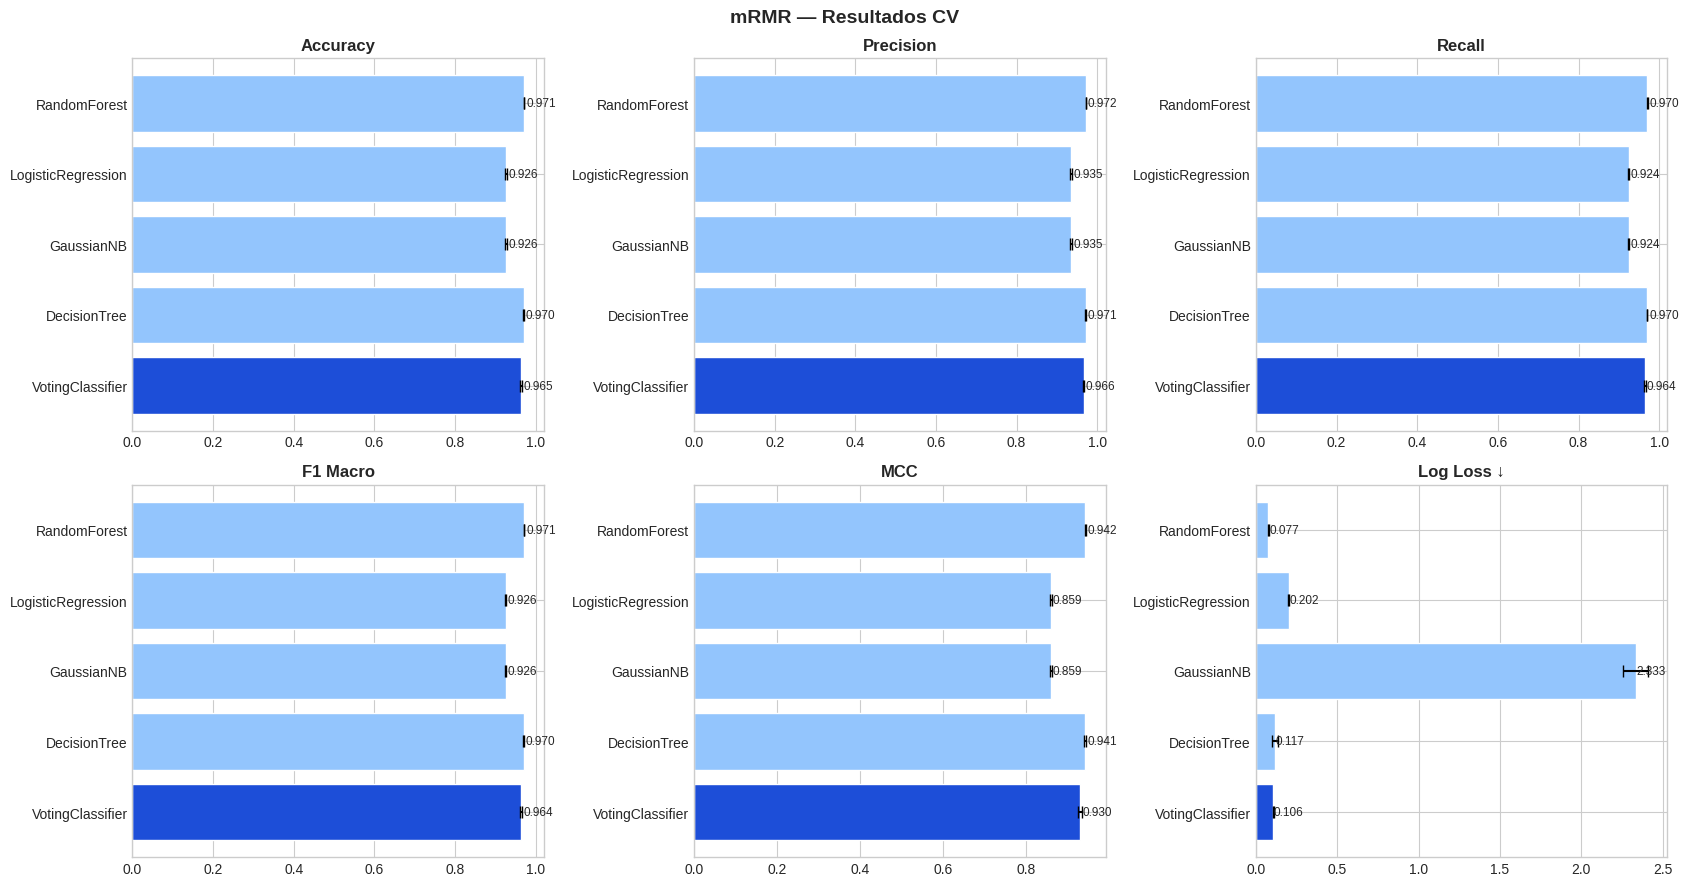


════════════════════════════════════════════════════════════
 Avaliando seletor: Fisher
════════════════════════════════════════════════════════════
  [Fold 1/5] Fisher — tunando…
  [Fold 2/5] Fisher — tunando…
  [Fold 3/5] Fisher — tunando…
  [Fold 4/5] Fisher — tunando…
  [Fold 5/5] Fisher — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Fisher,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Fisher,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201880,0.004330
2,Fisher,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.332981,0.074302
3,Fisher,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
4,Fisher,VotingClassifier,0.964122,0.000979,0.965797,0.000826,0.963201,0.001038,0.963988,0.000989,0.928994,0.001854,0.105788,0.002377


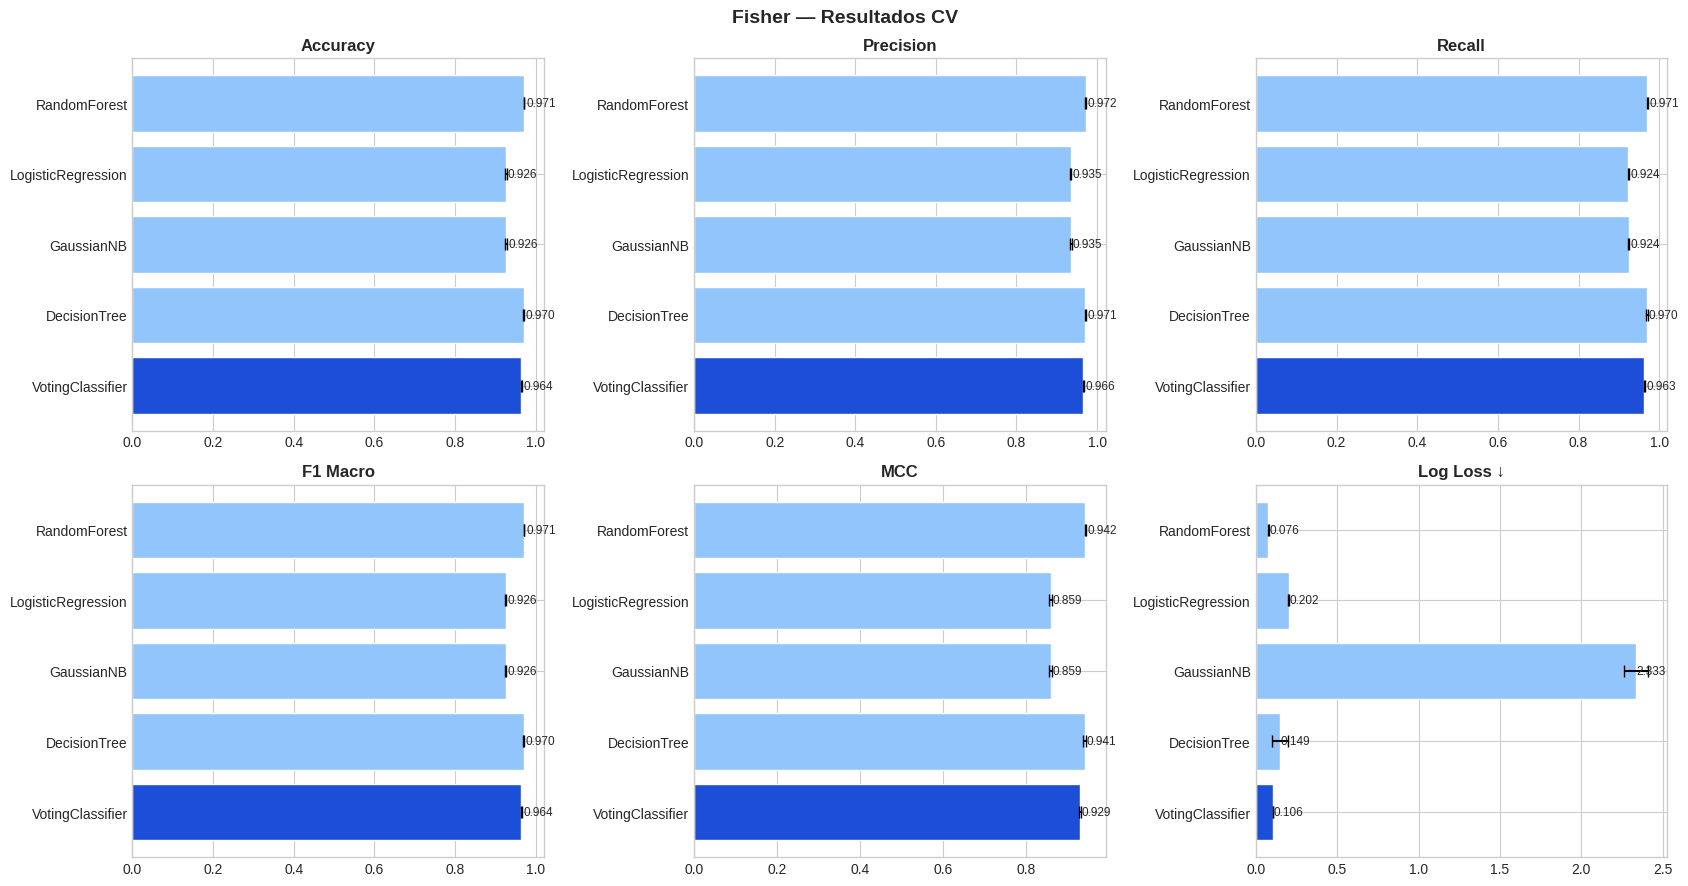


════════════════════════════════════════════════════════════
 Avaliando seletor: Pearson
════════════════════════════════════════════════════════════
  [Fold 1/5] Pearson — tunando…
  [Fold 2/5] Pearson — tunando…
  [Fold 3/5] Pearson — tunando…
  [Fold 4/5] Pearson — tunando…
  [Fold 5/5] Pearson — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Pearson,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Pearson,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201880,0.004330
2,Pearson,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.332981,0.074302
3,Pearson,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
4,Pearson,VotingClassifier,0.964122,0.000979,0.965797,0.000826,0.963201,0.001038,0.963988,0.000989,0.928994,0.001854,0.105788,0.002377


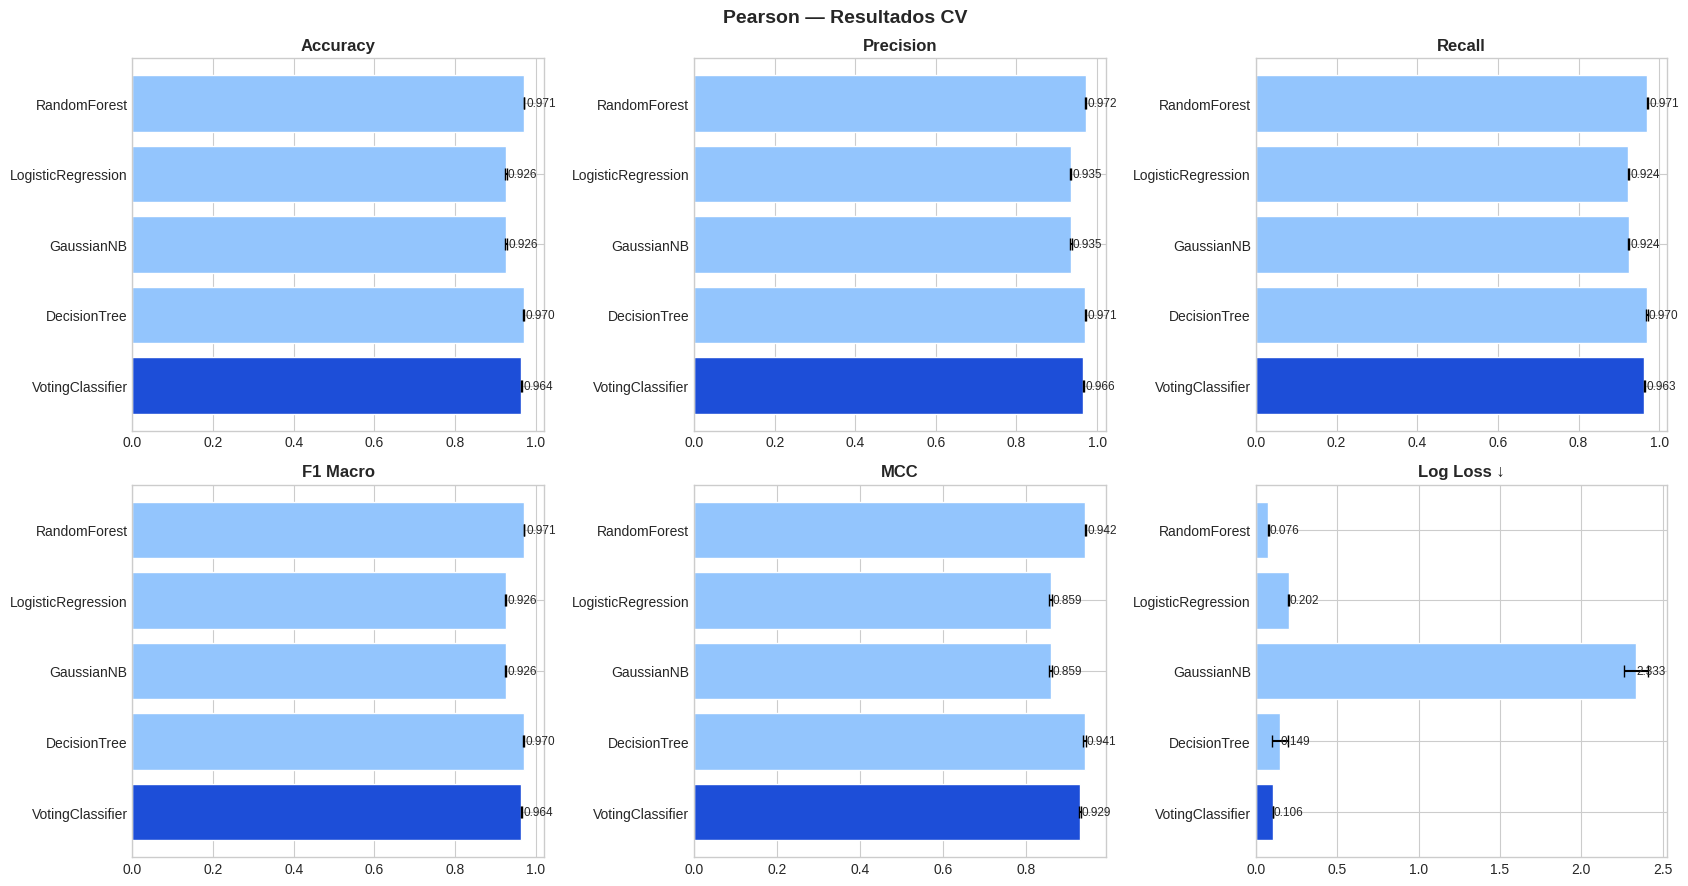


════════════════════════════════════════════════════════════
 Avaliando seletor: ExtraTrees
════════════════════════════════════════════════════════════
  [Fold 1/5] ExtraTrees — tunando…
  [Fold 2/5] ExtraTrees — tunando…
  [Fold 3/5] ExtraTrees — tunando…
  [Fold 4/5] ExtraTrees — tunando…
  [Fold 5/5] ExtraTrees — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,ExtraTrees,RandomForest,0.971139,0.000850,0.971881,0.000771,0.970599,0.000905,0.971063,0.000857,0.942478,0.001638,0.076169,0.002487
1,ExtraTrees,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201880,0.004330
2,ExtraTrees,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.332981,0.074302
3,ExtraTrees,DecisionTree,0.970621,0.001144,0.971232,0.001114,0.970138,0.001168,0.970548,0.001148,0.941369,0.002266,0.162353,0.046455
4,ExtraTrees,VotingClassifier,0.964301,0.001558,0.965966,0.001388,0.963385,0.001625,0.964169,0.001571,0.929347,0.003005,0.105498,0.002175


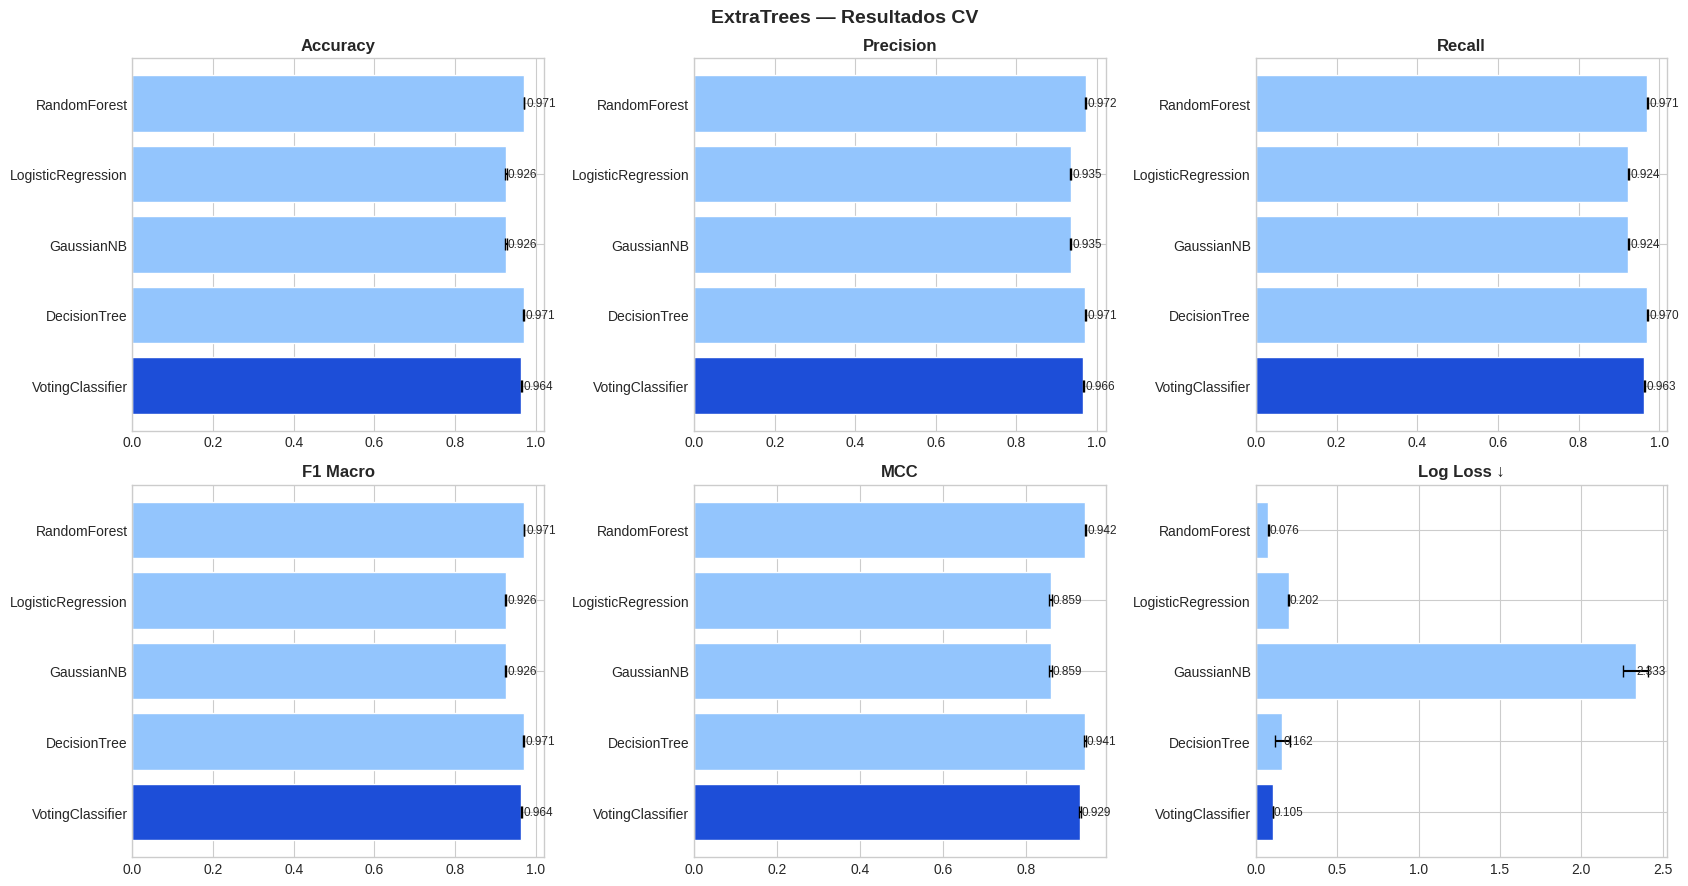


════════════════════════════════════════════════════════════
 Avaliando seletor: LinearSVC_L1
════════════════════════════════════════════════════════════
  [Fold 1/5] LinearSVC_L1 — tunando…
  [Fold 2/5] LinearSVC_L1 — tunando…
  [Fold 3/5] LinearSVC_L1 — tunando…
  [Fold 4/5] LinearSVC_L1 — tunando…
  [Fold 5/5] LinearSVC_L1 — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LinearSVC_L1,RandomForest,0.971223,0.001131,0.972100,0.001009,0.970624,0.001196,0.971143,0.001139,0.942722,0.002182,0.076373,0.003290
1,LinearSVC_L1,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201875,0.004310
2,LinearSVC_L1,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.212170,0.066502
3,LinearSVC_L1,DecisionTree,0.970388,0.000990,0.971037,0.000986,0.969888,0.001010,0.970314,0.000994,0.940924,0.001971,0.123342,0.047390
4,LinearSVC_L1,VotingClassifier,0.964153,0.001223,0.965814,0.001067,0.963238,0.001285,0.964020,0.001234,0.929048,0.002343,0.106009,0.002308


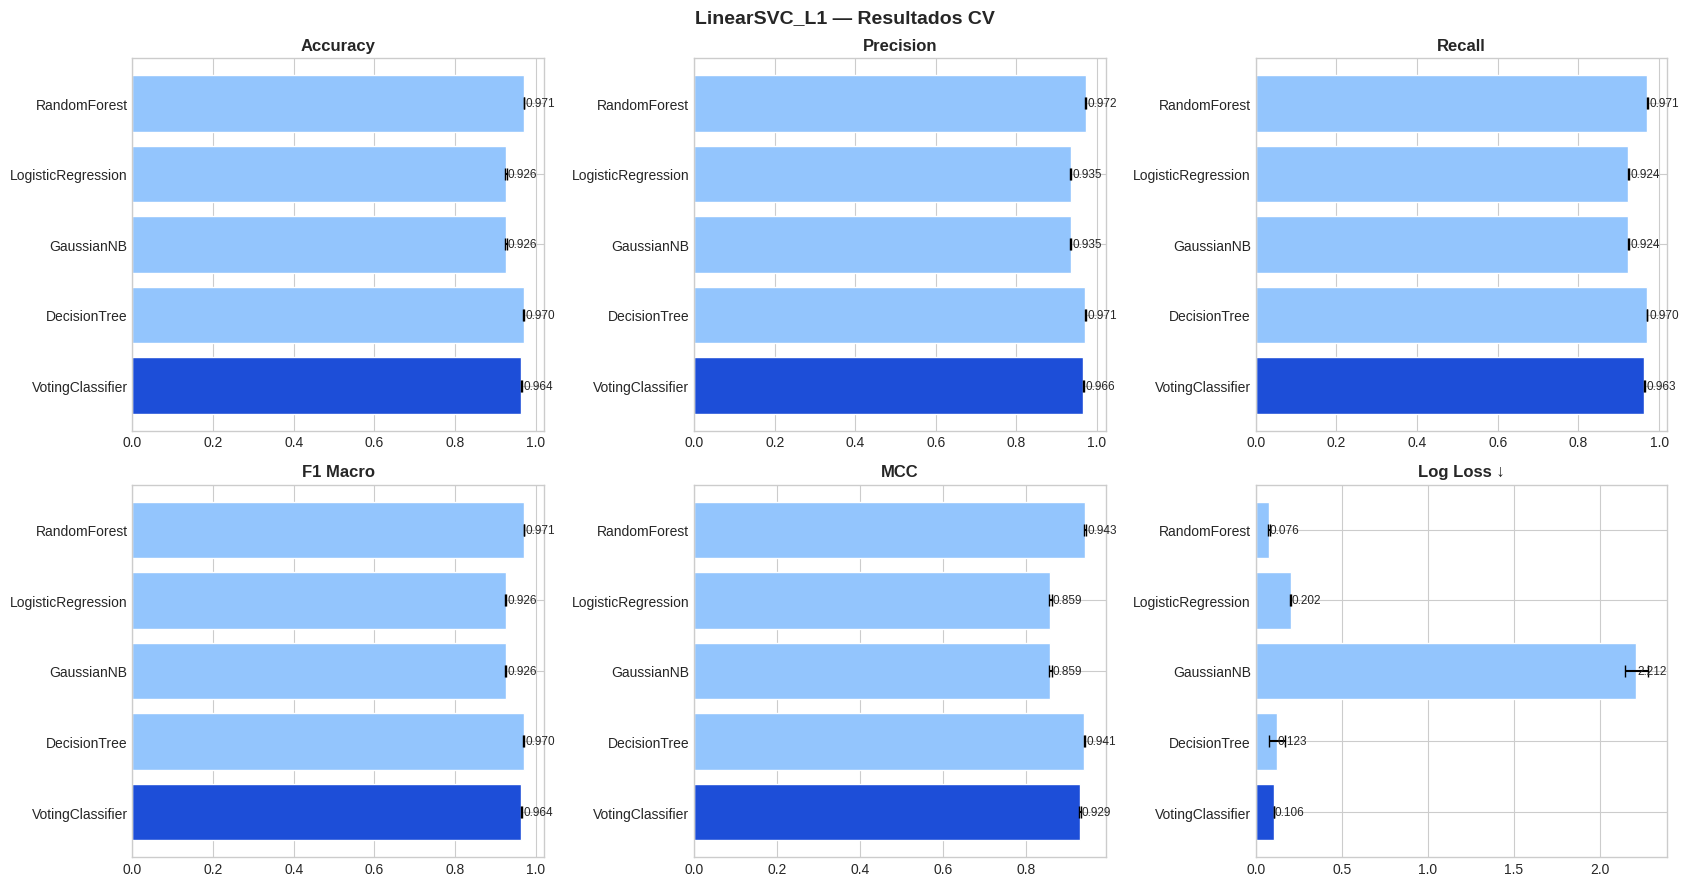


════════════════════════════════════════════════════════════
 Avaliando seletor: LassoCV
════════════════════════════════════════════════════════════
  [Fold 1/5] LassoCV — tunando…
  [Fold 2/5] LassoCV — tunando…
  [Fold 3/5] LassoCV — tunando…
  [Fold 4/5] LassoCV — tunando…
  [Fold 5/5] LassoCV — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LassoCV,RandomForest,0.971170,0.001037,0.972010,0.000832,0.970594,0.001149,0.971091,0.001049,0.942602,0.001938,0.076891,0.001895
1,LassoCV,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201875,0.004309
2,LassoCV,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,1.898554,0.060268
3,LassoCV,DecisionTree,0.970293,0.000859,0.971078,0.000666,0.969732,0.000954,0.970213,0.000869,0.940808,0.001593,0.176879,0.032461
4,LassoCV,VotingClassifier,0.963995,0.001437,0.965685,0.001238,0.963070,0.001512,0.963860,0.001450,0.928751,0.002741,0.106079,0.002344


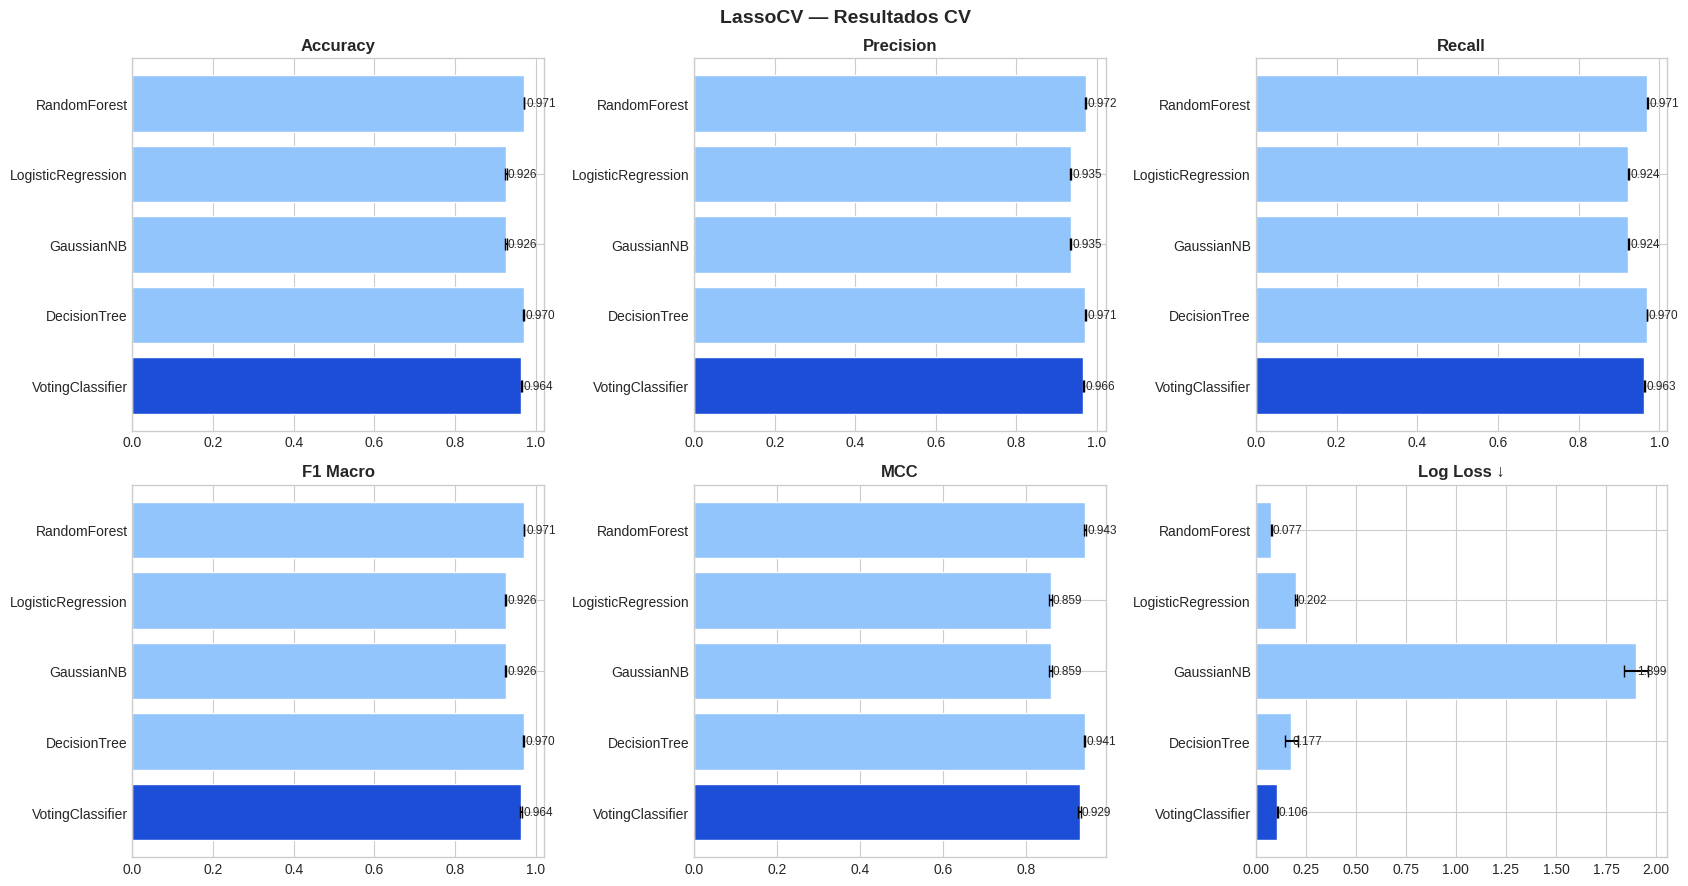


════════════════════════════════════════════════════════════
 Avaliando seletor: LowVariance
════════════════════════════════════════════════════════════
  [Fold 1/5] LowVariance — tunando…
  [Fold 2/5] LowVariance — tunando…
  [Fold 3/5] LowVariance — tunando…
  [Fold 4/5] LowVariance — tunando…
  [Fold 5/5] LowVariance — tunando…


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LowVariance,RandomForest,0.971128,0.000771,0.971913,0.000644,0.970568,0.000848,0.971051,0.000779,0.942481,0.001458,0.075692,0.002096
1,LowVariance,LogisticRegression,0.926383,0.001704,0.935031,0.001480,0.923869,0.001750,0.925620,0.001739,0.858828,0.003213,0.201881,0.004330
2,LowVariance,GaussianNB,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,2.332981,0.074302
3,LowVariance,DecisionTree,0.969596,0.001147,0.970608,0.000978,0.968944,0.001247,0.969506,0.001159,0.939550,0.002161,0.124773,0.050767
4,LowVariance,VotingClassifier,0.964608,0.001931,0.966265,0.001796,0.963694,0.001984,0.964477,0.001943,0.929956,0.003775,0.106210,0.002340


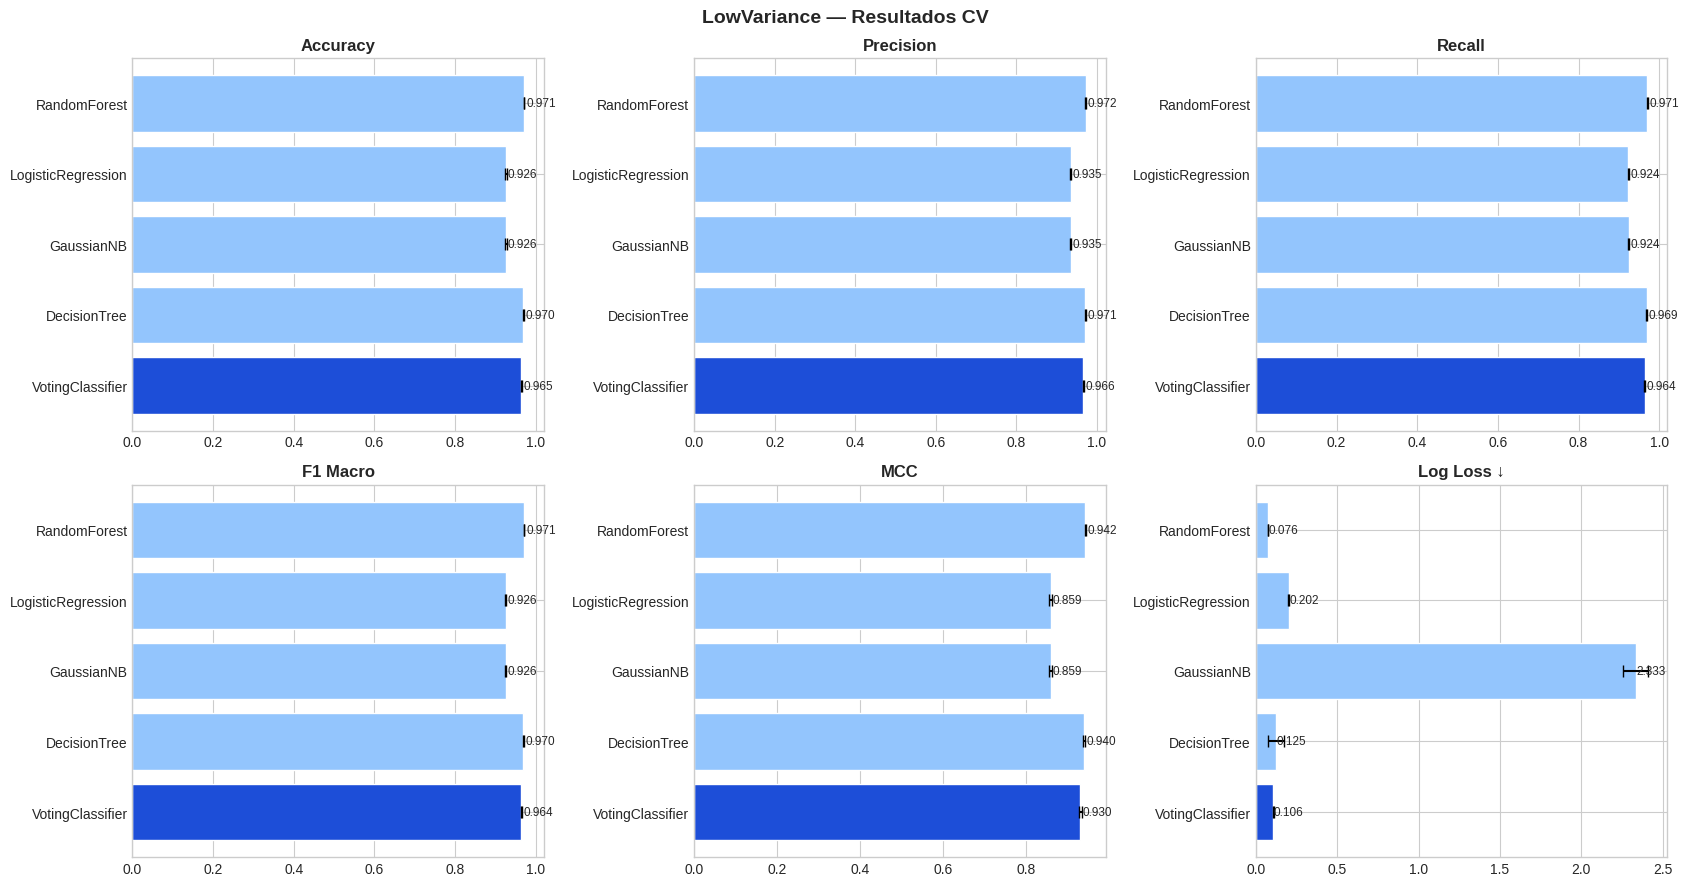


────────────────────────────────────────────────────────────
 COMPARAÇÃO GLOBAL: todos os seletores × modelos
────────────────────────────────────────────────────────────


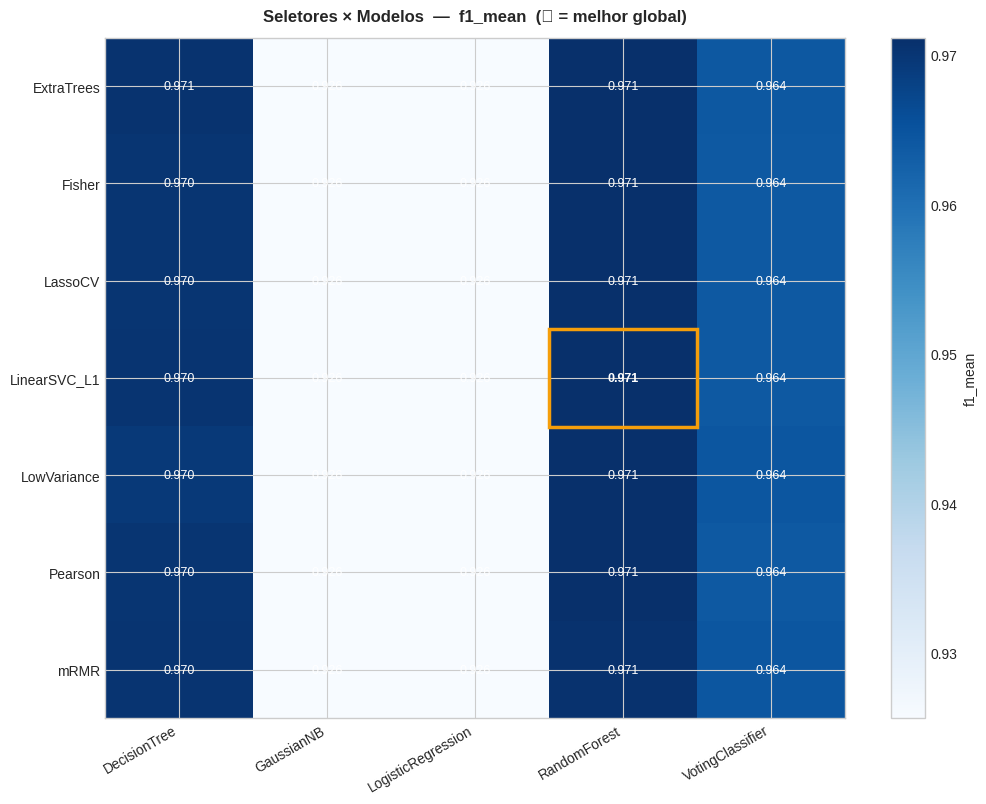


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  MELHOR COMBINAÇÃO  —  ordenado por f1_mean
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  Seletor : LinearSVC_L1
  Modelo  : RandomForest

  ── Métricas ──────────────────────────────────────────
    accuracy_mean          0.9712
    accuracy_std           0.0011
    precision_mean         0.9721
    precision_std          0.0010
    recall_mean            0.9706
    recall_std             0.0012
    f1_mean                0.9711
    f1_std                 0.0011
    mcc_mean               0.9427
    mcc_std                0.0022
    logloss_mean           0.0764
    logloss_std            0.0033

  ── Hiperparâmetros (agregados entre folds) ────────────
    n_estimators              370
    max_depth                 10
    min_samples_split         15
    min_samples_leaf          3
    max_features              sqrt
    bootstrap                 1
    random_state              42
    n_jobs               

,selector,model,param,best_value
0,mRMR,RandomForest,n_estimators,300
1,mRMR,RandomForest,max_depth,13
2,mRMR,RandomForest,min_samples_split,12
3,mRMR,RandomForest,min_samples_leaf,7
4,mRMR,RandomForest,max_features,log2
...,...,...,...,...
142,LowVariance,DecisionTree,min_samples_leaf,7
143,LowVariance,DecisionTree,criterion,gini
144,LowVariance,DecisionTree,max_features,log2
145,LowVariance,DecisionTree,splitter,best


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURAÇÃO DA EXECUÇÃO                       ║
# ╚══════════════════════════════════════════════════════════════╝
CV_SPLITS        = 5     # folds do CV externo
N_OPTUNA_TRIALS  = 30    # tentativas Optuna por modelo por fold
VOTING_MODE      = "soft"
RANK_METRIC      = "f1_mean"  # métrica para eleger o melhor par

# ── Executa todos os seletores ────────────────────────────────────
df_all, hyperparams_all = run_all_selectors(
    selector_funcs  = selector_funcs,
    X               = X,
    y               = y,
    cv_splits       = CV_SPLITS,
    n_optuna_trials = N_OPTUNA_TRIALS,
    voting          = VOTING_MODE,
)

# ── Heatmap comparativo global ────────────────────────────────────
print("\n" + "─" * 60)
print(" COMPARAÇÃO GLOBAL: todos os seletores × modelos")
print("─" * 60)
plot_selector_comparison(df_all, metric=RANK_METRIC)

# ── Melhor par e seus hiperparâmetros ─────────────────────────────
best_result = find_best_pair(df_all, hyperparams_all, metric=RANK_METRIC)

# ── Tabela completa de hiperparâmetros ────────────────────────────
print("\n── Tabela completa de melhores hiperparâmetros ──────────")
display(summarize_best_hyperparams(hyperparams_all))
